# **Procesamiento de Lenguaje Natural**
## **MNA - Tecnológico de Monterrey**
## **Algunos ejemplos para extraer el texto de un archivo de audio.**

# **Caso - 1: modelos whisper de OpenAI con HuggingFace**

* #### **Se tienen diferentes variantes de código abierto de whisper de OpenAI con HuggingFace:**

 https://huggingface.co/models?sort=trending&search=openai%2Fwhisper-

* #### **Estos modelos no requieren el uso de la API de OpenAI.**

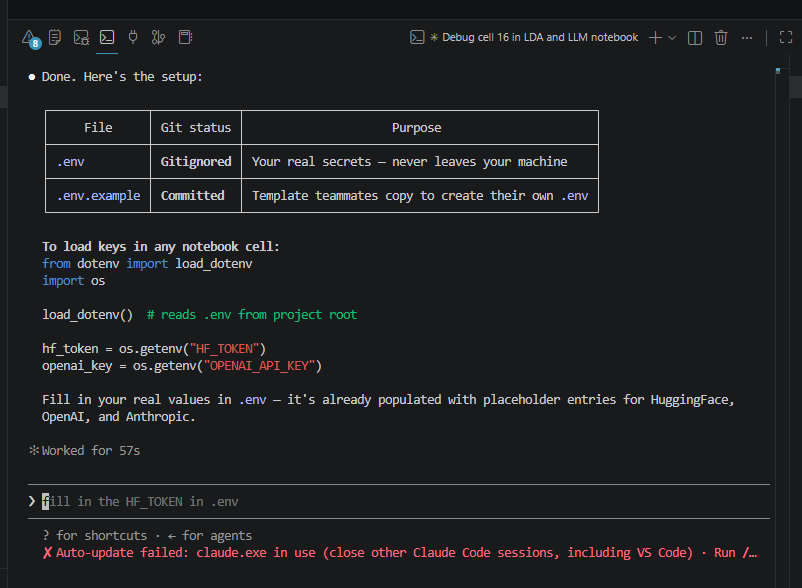

#### **Se recomienda el uso de GPU**

In [ ]:
#!pip install transformers accelerate
#!apt-get install -y ffmpeg   # si trabajas en tu computadora necesitarás FFMPEG para manejo de archivos de audio y música

In [2]:
import torch
from transformers import pipeline
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
import librosa   # paquete para audio y música
from dotenv import load_dotenv
import os

load_dotenv()  # reads .env from project root
hf_token = os.getenv("HF_TOKEN")

import warnings
# para filtrar advertencias:
warnings.filterwarnings("ignore")

In [3]:
# Descargamos el archivo de audio:
!gdown "https://www.gutenberg.org/files/20029/mp3/20029-01.mp3"

Downloading...
From: https://www.gutenberg.org/files/20029/mp3/20029-01.mp3
To: d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\notebooks\Clase5\20029-01.mp3

  0%|          | 0.00/1.18M [00:00<?, ?B/s]
 45%|████▍     | 524k/1.18M [00:00<00:00, 1.68MB/s]
100%|██████████| 1.18M/1.18M [00:00<00:00, 2.98MB/s]


In [4]:
# Con librosa podemos obtener información del archivo:
audio_path = r"D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase5\audios_esopo\21144-01.mp3"
audio, sample_rate = librosa.load(audio_path, sr=16000)
print(f"Duración del audio: {len(audio)/sample_rate:.1f} segundos")

Duración del audio: 72.6 segundos


In [5]:
# <Opcional: si deseas escucharlo>
from IPython.display import Audio
Audio(audio_path)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [7]:
# Puedes seleccionar algunas de las siguientes versiones de whisper.
# Revisa la documentación de cada uno en HuggingFace.

#model_id="openai/whisper-tiny"    # el más sencillo y ligero, pero menos preciso.
#model_id="openai/whisper-small"
#model_id="openai/whisper-base"
#model="openai/whisper-medium"  # Generalmente el modelo intermedio en cuanto a desempeño y tamaño.
#model_id = "openai/whisper-large-v3"    # mejor modelo
model_id = "openai/whisper-large-v3-turbo"    # una versión ligera de v3

# Cargamos el modelo:
processor = AutoProcessor.from_pretrained(model_id)
modelo = AutoModelForSpeechSeq2Seq.from_pretrained(model_id).to(device)


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

In [8]:
# Inicializamos el pipeline:
pipe = pipeline("automatic-speech-recognition",
                model=modelo,
                tokenizer=processor.tokenizer,
                feature_extractor=processor.feature_extractor,
                torch_dtype=torch.float32,      #torch.float16 if torch.cuda.is_available() else torch.float32,
                device=device
                )

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


In [9]:
# Extraemos el texto del audio:
result = pipe(audio,
              return_timestamps=True,   # Para audios mayores a 30 segs.
              generate_kwargs={"language":"es"}  # Lo detecta automático, pero se le puede indicar el idioma.
              )

[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


In [10]:
result["text"]   # el texto del audio

' Las Fábulas de Esopo, grabado para LibriVox.org por Paulino, www.paulino.info. Fábula número 61. El Lobo y el Cordero en el Templo. Dándose cuenta de que era perseguido por un lobo, un pequeño corderito decidió refugiarse en un templo cercano. Lo llamó lobo y le dijo que si el sacrificador lo encontraba allí adentro, lo enmolaría a su dios. Mejor así, replicó el cordero, prefiero ser víctima para un dios a tener que perecer en tus colmillos. Si sin remedio vamos a ser sacrificados, más nos vale que sea con el mayor honor. Fin de la fábula Esta es una grabación del dominio público.'

In [ ]:
result

# **Caso - 2: modelo whisper-1 de OpenAI ... requiere uso de la API de OpenAI**

#### **Revisa la documentación del modelo "whisper-1":** https://platform.openai.com/docs/models/whisper-1

In [ ]:
!pip install openai

In [ ]:
from google.colab import userdata
from openai import OpenAI
import openai

In [ ]:
api_key = userdata.get("miOpenAI_API_key")

if not api_key:
  raise ValueError("API key no encontrada en los secretos")

In [ ]:
# Crear cliente con tu clave de API
client = OpenAI(api_key=api_key)

# Ruta del archivo de audio en audio_path.
# Abrimos el archivo en binario y extraemos el texto con whisper-1:
with open(audio_path, "rb") as audio_file:
    transcript = client.audio.transcriptions.create(model="whisper-1",
                                                    file=audio_file,
                                                    language="es"
                                                    )

In [ ]:
transcript.text   # en particular observa el formato de la salida del texto.

# **Caso - 3: otros modelos en HuggingFace**

* #### **Los modelos Wav2Vec2 abarcan una gran variedad de problemáticas, son modelos abiertos de Meta y muchos de ellos los podemos encontrar en HuggingFace.**

* #### **Estos modelos fueron entrenados con datos muestreados a 16 Hz, por lo que se debe verificar que los datos de entrada tengan esta característica.**

In [ ]:
#!pip install transformers librosa

In [11]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import librosa
import torch

In [12]:
#from google.colab import userdata
from huggingface_hub import login
login()

In [13]:
#login(userdata.get('barajas_angel'))

In [14]:
# Verificamos si hay GPU disponible:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [15]:
audio_path = r"D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase5\audios_esopo\21144-01.mp3"
audio, sample_rate = librosa.load(audio_path,
                                  sr=16000   # los modelos Wav2Vec2 requieren un muestreo (sample rate) de 16Hz.
                                  )
print(f"Duración del audio: {len(audio)/sample_rate:.1f} segundos")

Duración del audio: 72.6 segundos


In [16]:
# Modelos entrenados específicamente con datos en español.
# Recuerda revisar la documentación de cada uno en HuggingFace.

model_name = "facebook/wav2vec2-large-xlsr-53-spanish"
#model_name = "jonatasgrosman/wav2vec2-large-xlsr-53-spanish"
#model_name="facebook/wav2vec2-base-10k-voxpopuli-ft-es"

# Cargamos el modelo y el procesador:
processor = Wav2Vec2Processor.from_pretrained(model_name)
modelo = Wav2Vec2ForCTC.from_pretrained(model_name).to(device)


Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

In [17]:
# Convertimos los datos a un tensor de pyTorch con el muestro seleccionado:
input_values = processor(audio,
                         sampling_rate=sample_rate,
                         return_tensors="pt").input_values.to(device)


In [18]:
# Realizamos las inferencias sin calcular los gradientes para optimizar recursos,
# ya que no estamos haciendo ajuste de parámetros (fine-tuning):
with torch.no_grad():
    logits = modelo(input_values).logits


In [19]:
# Decodificamos la salida:
predicted_ids = torch.argmax(logits, dim=-1)   # seleccionamos las salidas (ids) de mayor probabilidad.
transcription = processor.decode(predicted_ids[0])   # obtenemos los tokens (palabras) con los ids.

In [20]:
transcription   # observa que en este modelo la introducción y el cierre del audio se excluyen de manera automática.

'fábulaesopo rcppaulinopaul el lobo y el cordero en el templo dándose cuenta de que era perseguido por un lobo un pequeño corderito decidió refugiarse en un templo cercano lo llamó lobo y le dijo que si el sacrificador lo encontraba allí adentro lo enmolaría a su dios mejor así replicó el cordero prefiero ser víctima para un dios a tener que perecer en tus colmillos si sin remedio vamos a ser sacrificados más nos vale que sea con el mayor honor fábula'

# **Caso - 4: Google-Translator**

* #### **Esta opción está basada en el traductor de Google y no solo soporta una gran variedad de idiomas, sino también una buena variedad de acentos para un mismo idioma. En particular para el español existen versiones para diversos acentos de países de latinoamérica.**

* #### **Requiere que el archivo de entrada esté en formato de audio WAV.**

* #### **Es gratuita, pero tiene restricciones si hacemos muchas solicitudes en poco tiempo, en cuyo caso se requiere hacer uso de su API y por lo tanto tendrá un costo. Consulta la documentación.**

* #### **Puedes verifica los idiomas y variantes soportadas en la siguiente liga:**

https://cloud.google.com/speech-to-text/docs/speech-to-text-supported-languages?hl=es-419

* #### **Documentación de SpeechRecognition:** https://pypi.org/project/SpeechRecognition/

In [ ]:
#install in terminal
#!pip install SpeechRecognition pydub

In [21]:
from pydub import AudioSegment
import speech_recognition as sr
import os

from IPython.display import Markdown, display

In [22]:
import imageio_ffmpeg

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
print(ffmpeg_exe)

d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [23]:
import os
import imageio_ffmpeg

ffmpeg_dir = os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())
os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ["PATH"]

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()

print(ffmpeg_exe)
print(os.path.exists(ffmpeg_exe))

d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe
True


In [31]:
from pydub import AudioSegment
import imageio_ffmpeg
import os

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()

AudioSegment.converter = ffmpeg_exe
AudioSegment.ffmpeg = ffmpeg_exe
AudioSegment.ffprobe = ffmpeg_exe   # importante

os.environ["PATH"] = os.path.dirname(ffmpeg_exe) + os.pathsep + os.environ["PATH"]

print(ffmpeg_exe)

d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [34]:
import subprocess
import imageio_ffmpeg
import os

ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()

audio_mp3_path = r"D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase5\audios_esopo\21144-01.mp3"
wav_file = r"D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\clase5\audios_esopo\tmp.wav"

subprocess.run([
    ffmpeg_exe,
    "-y",
    "-i", audio_mp3_path,
    "-ar", "16000",
    "-ac", "1",
    wav_file
], check=True)

print("WAV creado en:", wav_file)
print(os.path.exists(wav_file))

WAV creado en: D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\clase5\audios_esopo\tmp.wav
True


In [35]:
# Inicializamos el reconocedor:
recognizer = sr.Recognizer()

# Cargamos y analizamos el archivo en formato WAV:
with sr.AudioFile(wav_file) as source:

    audio_data = recognizer.record(source)  # extracción de los datos del audio

    try:
        # Procedemos con la extracción del texto.
        # Estoy usando la pronunciación que tiene para México,
        # pero en dado caso puede cambiarse:
        texto = recognizer.recognize_google(audio_data,
                                            language="es-MX"
                                            )
        display(Markdown(texto))  # para darle cierto formato a la salida

    except sr.UnknownValueError:
        print("No se pudo entender el audio")
    except sr.RequestError as e:
        print(f"No se pudo solicitar resultados al servicio de reconocimiento; {e}")


las fábulas de Esopo grabado para librivox.org por Paulino www.paulinas.com.mx en un templo cercano lo llamó el lobo y le dijo que si el sacrificador lo encontraba allí adentro lo demoraría a su Dios mejor así replicó el cordero Prefiero ser víctima para un Dios a tener que perecer en tus colmillos y sin remedio vamos a ser sacrificados más nos vale que sea con el mayor honor fin de la fábula Esta es una grabación del dominio público

In [36]:
texto

'las fábulas de Esopo grabado para librivox.org por Paulino www.paulinas.com.mx en un templo cercano lo llamó el lobo y le dijo que si el sacrificador lo encontraba allí adentro lo demoraría a su Dios mejor así replicó el cordero Prefiero ser víctima para un Dios a tener que perecer en tus colmillos y sin remedio vamos a ser sacrificados más nos vale que sea con el mayor honor fin de la fábula Esta es una grabación del dominio público'

In [37]:
# removemos el archivo WAV temporal:
os.remove(wav_file)